In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fraud = pd.read_csv("../data/raw/Fraud_Data.csv")

fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
fraud.shape

(151112, 11)

In [4]:
fraud.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [5]:
fraud = fraud.dropna()

In [6]:
fraud.duplicated().sum()

np.int64(0)

In [7]:
fraud["signup_time"] = pd.to_datetime(fraud["signup_time"])
fraud["purchase_time"] = pd.to_datetime(fraud["purchase_time"])

In [8]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.7+ MB


In [9]:
fraud["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [10]:
fraud["class"].value_counts(normalize=True)*100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

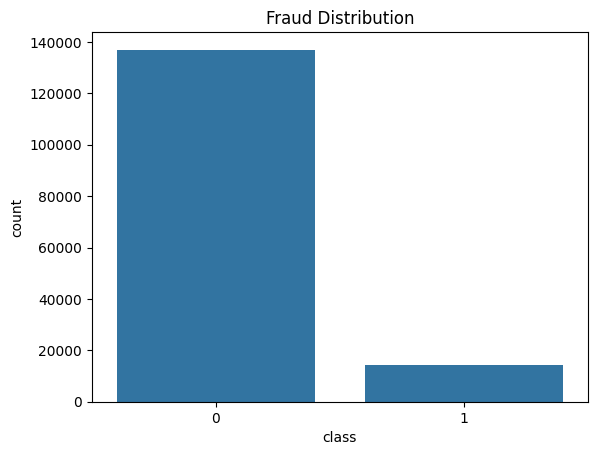

In [11]:
sns.countplot(data=fraud,x="class")
plt.title("Fraud Distribution")
plt.show()

Dataset is highly imbalanced with fraud cases representing only 9%.

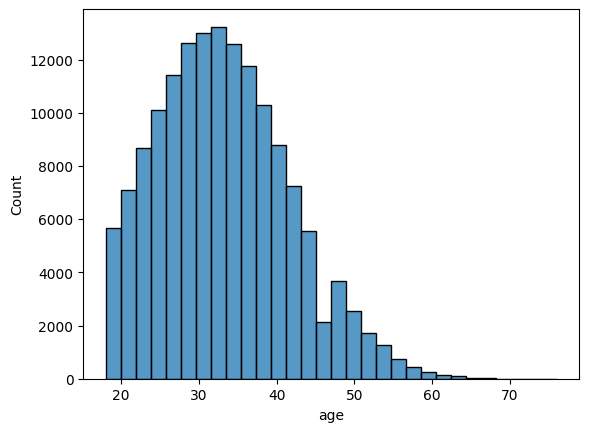

In [12]:
sns.histplot(fraud["age"], bins=30)
plt.show()

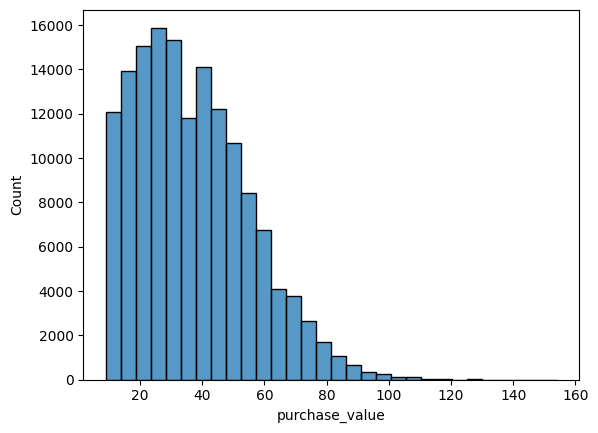

In [13]:
sns.histplot(fraud["purchase_value"], bins=30)
plt.show()

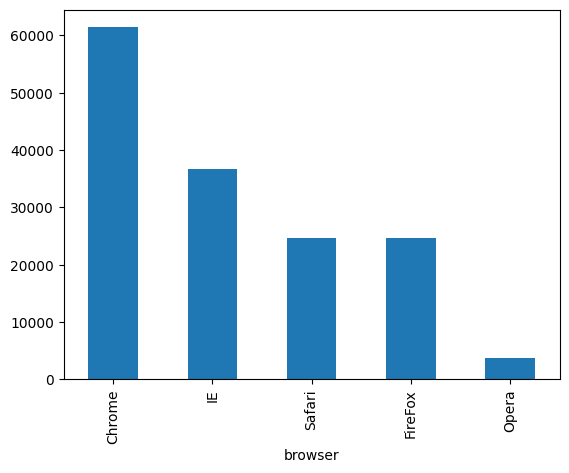

In [15]:
fraud["browser"].value_counts().plot(kind="bar")
plt.show()

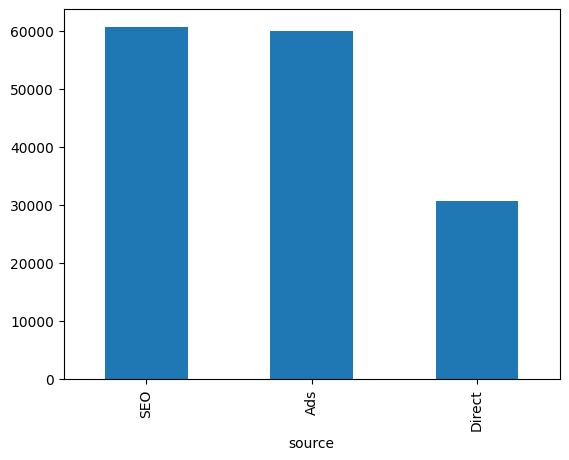

In [14]:
fraud["source"].value_counts().plot(kind="bar")
plt.show()

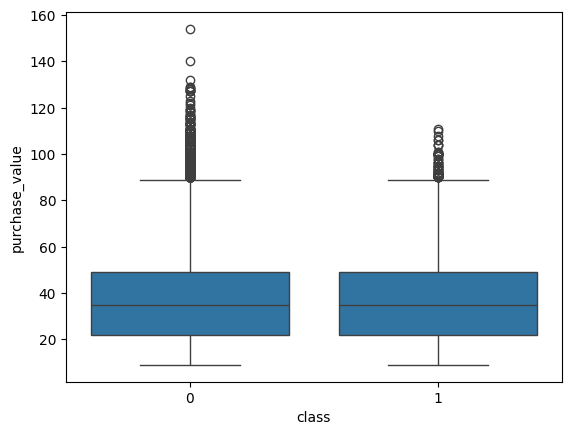

In [16]:
sns.boxplot(
    x="class",
    y="purchase_value",
    data=fraud
)
plt.show()

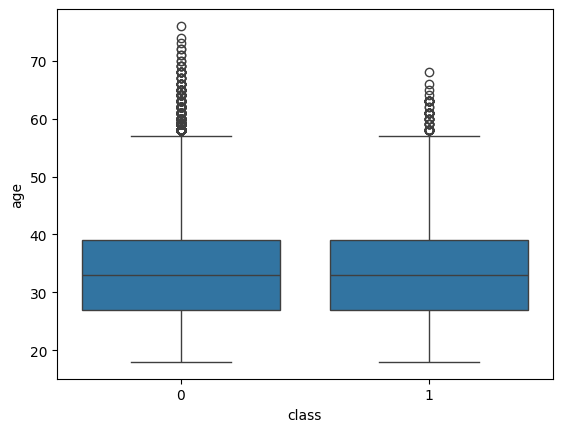

In [17]:
sns.boxplot(
    x="class",
    y="age",
    data=fraud
)
plt.show()

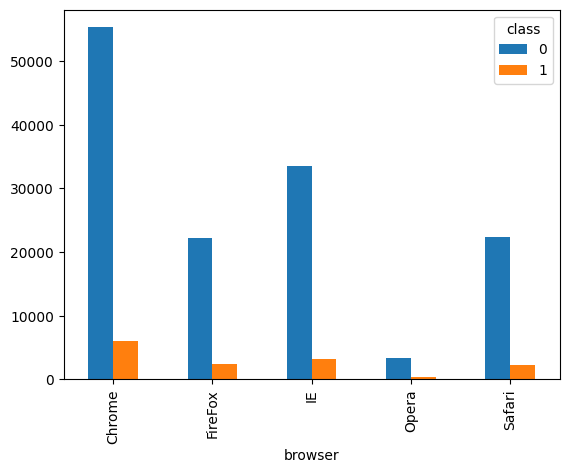

In [18]:
pd.crosstab(
    fraud["browser"],
    fraud["class"]
).plot(kind="bar")
plt.show()

In [19]:
ip = pd.read_csv(
    "../data/raw/IpAddress_to_Country.csv"
)

In [20]:
fraud["ip_address"] = fraud["ip_address"].astype(np.int64)

ip["lower_bound_ip_address"] = (
    ip["lower_bound_ip_address"].astype(np.int64)
)

ip["upper_bound_ip_address"] = (
    ip["upper_bound_ip_address"].astype(np.int64)
)

In [21]:
fraud = fraud.sort_values("ip_address")

ip = ip.sort_values(
    "lower_bound_ip_address"
)

In [22]:
fraud_geo = pd.merge_asof(
    fraud,
    ip,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [23]:
fraud_geo = fraud_geo[
    fraud_geo["ip_address"]
    <= fraud_geo["upper_bound_ip_address"]
]

In [24]:
fraud_geo["country"].value_counts().head(20)

country
United States                      58049
China                              12038
Japan                               7306
United Kingdom                      4490
Korea Republic of                   4162
Germany                             3646
France                              3161
Canada                              2975
Brazil                              2961
Italy                               1944
Australia                           1844
Netherlands                         1680
Russian Federation                  1616
India                               1310
Taiwan; Republic of China (ROC)     1237
Mexico                              1121
Sweden                              1090
Spain                               1027
South Africa                         838
Switzerland                          785
Name: count, dtype: int64

In [25]:
country_fraud = fraud_geo.groupby(
    "country"
)["class"].mean()

country_fraud.sort_values(
    ascending=False
).head(20)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
Malta                    0.181818
Afghanistan              0.166667
Cote D'ivoire            0.166667
Denmark                  0.159184
Chile                    0.153477
Name: class, dtype: float64

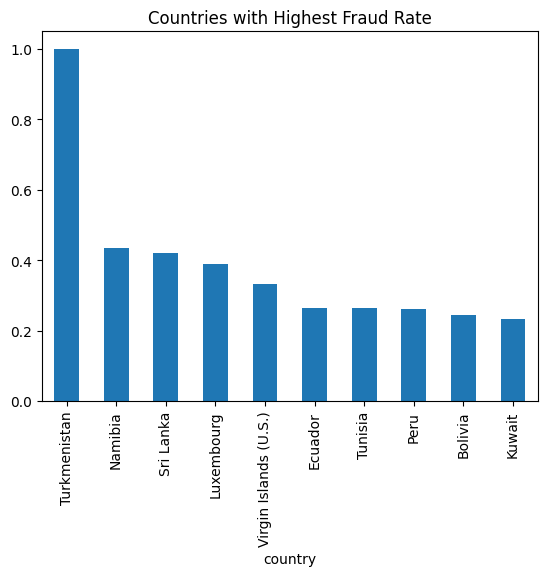

In [26]:
country_fraud.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)

plt.title(
    "Countries with Highest Fraud Rate"
)

plt.show()

In [27]:
fraud_geo.to_csv("../data/processed/fraud_with_country.csv", index=False)